In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

c:\Users\pc\miniconda3\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\pc\miniconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:
vocab_size = 10000 #Top 10,000 most common words
#Rare words removed.
#Why?
#Faster training
#Less memory
#Better generalization

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step


c:\Users\pc\miniconda3\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


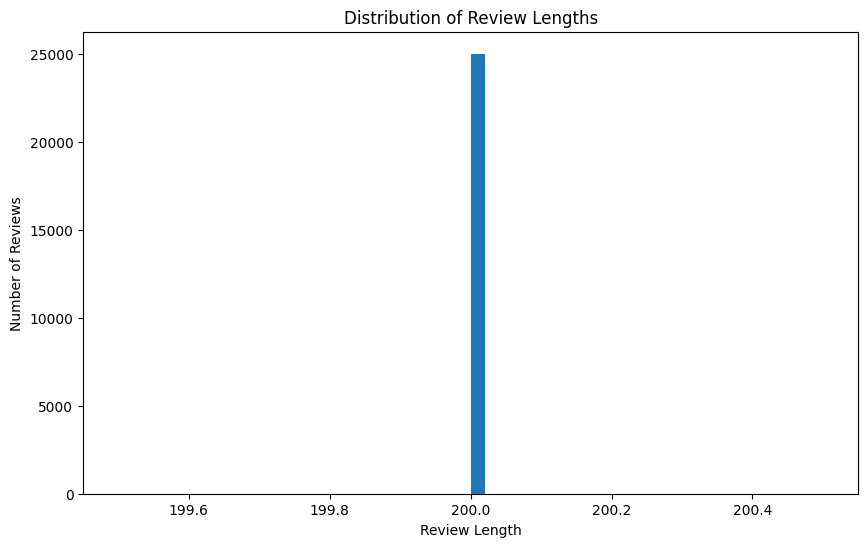

In [7]:
import matplotlib.pyplot as plt

# Calculate length of each review
review_lengths = [len(review) for review in x_train]

# Plot histogram
plt.figure(figsize=(10,6))

plt.hist(review_lengths, bins=50)

plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")

plt.show()

In [3]:
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

Transformers also have limits:

512 tokens
4096 tokens
etc.

Very long text:

chunking
summarization
RAG

use hota hai.

In [4]:
model = Sequential([
    
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_length),

    LSTM(128),

    Dense(1, activation='sigmoid')
])

c:\Users\pc\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 118s 293ms/step - accuracy: 0.7609 - loss: 0.4886 - val_accuracy: 0.7703 - val_loss: 0.4724
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 111s 284ms/step - accuracy: 0.8413 - loss: 0.3691 - val_accuracy: 0.8620 - val_loss: 0.3306
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 168s 350ms/step - accuracy: 0.9072 - loss: 0.2357 - val_accuracy: 0.8717 - val_loss: 0.3369
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 344ms/step - accuracy: 0.9344 - loss: 0.1758 - val_accuracy: 0.8680 - val_loss: 0.3516
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 130s 332ms/step - accuracy: 0.9510 - loss: 0.1360 - val_accuracy: 0.8656 - val_loss: 0.3691


In [8]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8656 - loss: 0.3691
Accuracy: 0.8655999898910522


TESTING

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load word index
word_index = imdb.get_word_index()

# Function to preprocess custom review
def encode_review(text):

    # Lowercase
    text = text.lower()

    # Split into words
    words = text.split()

    encoded = []

    for word in words:

        # Check word exists
        if word in word_index:

            # IMPORTANT: +3 offset
            index = word_index[word] + 3

            # Keep only vocab words
            if index < vocab_size:
                encoded.append(index)

        else:
            # Unknown word token
            encoded.append(2)

    # Pad sequence
    padded = pad_sequences(
        [encoded],
        maxlen=max_length
    )

    return padded


# ----------------------------
# TEST CUSTOM REVIEW
# ----------------------------

review = input("Enter movie review: ")

processed_review = encode_review(review)

prediction = model.predict(processed_review)

score = prediction[0][0]

print("\nPrediction Score:", score)

if score > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

Prediction Score: 0.8221048
Positive Review 😊
